R² : 0.0939337200384327
RMSE : 81.05648251338664


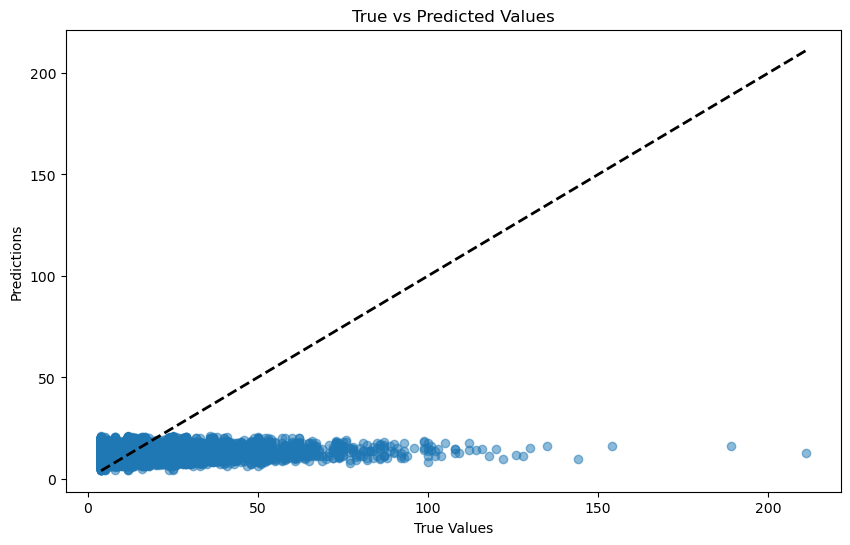

In [5]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, GridSearchCV, cross_val_predict, cross_validate
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Importation des données

path = os.path.join( "..", "data", "processed", "score_preprocessed.csv")
df = pd.read_csv(path)

# --- 1. Split
X = df.drop(columns="score")
y = df["score"]

# Tous les champs sont catégoriels → on les convertit en string
X = X.astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# --- 2. Pipeline : OHE (sparse) + régression linéaire
pipe = Pipeline([
    ("ohe", OneHotEncoder(handle_unknown="ignore", dtype=np.uint8)),
    ("reg", LinearRegression())
])

# --- 3. Entraînement
pipe.fit(X_train, y_train)

# --- 4. Prédiction & métriques
y_pred = pipe.predict(X_test)
from sklearn.metrics import r2_score, mean_squared_error
print("R² :", r2_score(y_test, y_pred))
print("RMSE :", mean_squared_error(y_test, y_pred)) 

# === 5. Visualisation des résultats
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values')
plt.show()

Epoch 1/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 1s 674us/step - loss: 107.8399 - mae: 6.8681 - val_loss: 86.2565 - val_mae: 5.9398
Epoch 2/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 0s 658us/step - loss: 82.1090 - mae: 5.9110 - val_loss: 85.7988 - val_mae: 5.9011
Epoch 3/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 0s 586us/step - loss: 85.7383 - mae: 5.8998 - val_loss: 86.0275 - val_mae: 6.0978
Epoch 4/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step - loss: 78.7297 - mae: 5.8597 - val_loss: 85.5178 - val_mae: 5.9361
Epoch 5/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step - loss: 83.8320 - mae: 5.8898 - val_loss: 85.5068 - val_mae: 5.9773
Epoch 6/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 0s 605us/step - loss: 83.3955 - mae: 5.8675 - val_loss: 85.4507 - val_mae: 5.9042
Epoch 7/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step - loss: 81.3703 - mae: 5.8727 - val_loss: 85.4691 - val_mae: 5.8358
Epoch 8/100
618/618 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step - loss: 84.3461 - mae: 5.8836 - val_loss: 85.7200 - val_mae: 6.0710
Epoch 9/100
618

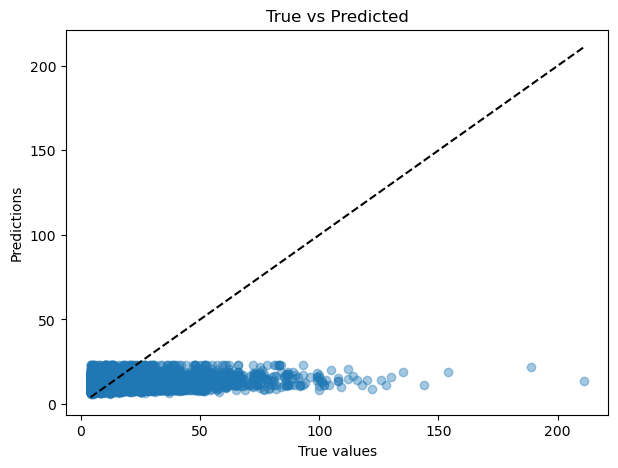

In [14]:
##################
# DNN 
##################

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier, KerasRegressor
import warnings
warnings.filterwarnings("ignore")

# Importation des données

path = os.path.join( "..", "data", "processed", "score_preprocessed.csv")
df = pd.read_csv(path)

# 0. Split -----------------------------------------------------------------
X = df.drop(columns=["score"]).astype(str)   # toutes catégorielles → str
y = df["score"]                              # variable continue

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 1. One-Hot (dense) --------------------------------------------------------
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
preproc = ColumnTransformer([("ohe", ohe, X.columns)], remainder="drop")

X_train_proc = preproc.fit_transform(X_train).astype("float32")
X_test_proc  = preproc.transform(X_test).astype("float32")

# 2. DNN pour régression ----------------------------------------------------
input_dim = X_train_proc.shape[1]
model = Sequential([
    Dense(128, activation="relu", input_shape=(input_dim,)),
    Dense(64,  activation="relu"),
    Dense(1,   activation="linear")          # ← 1 neurone, sortie continue
])

model.compile(optimizer="adam",
              loss="mse",                    # perte régression
              metrics=["mae"])

es = EarlyStopping(patience=5,
                   restore_best_weights=True,
                   monitor="val_loss")

# 3. Entraînement -----------------------------------------------------------
model.fit(X_train_proc,
          y_train,
          epochs=100,
          batch_size=256,
          validation_split=0.2,
          callbacks=[es],
          verbose=1)

# 4. Évaluation -------------------------------------------------------------
y_pred = model.predict(X_test_proc).flatten()

print("R²  :", r2_score(y_test, y_pred))
print("RMSE :", mean_squared_error(y_test, y_pred)) 


# 5. Visualisation ----------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.4)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "k--")
plt.xlabel("True values")
plt.ylabel("Predictions")
plt.title("True vs Predicted")
plt.show()

Epoch 1/100
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 1s 900us/step - loss: 0.4401 - mae: 0.5119 - val_loss: 0.2945 - val_mae: 0.4450
Epoch 2/100
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 1s 850us/step - loss: 0.2989 - mae: 0.4513 - val_loss: 0.2941 - val_mae: 0.4503
Epoch 3/100
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 1s 744us/step - loss: 0.2972 - mae: 0.4505 - val_loss: 0.2935 - val_mae: 0.4442
Epoch 4/100
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 1s 789us/step - loss: 0.2966 - mae: 0.4501 - val_loss: 0.2945 - val_mae: 0.4523
Epoch 5/100
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 1s 810us/step - loss: 0.2972 - mae: 0.4504 - val_loss: 0.2930 - val_mae: 0.4479
Epoch 6/100
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 1s 789us/step - loss: 0.2967 - mae: 0.4498 - val_loss: 0.2984 - val_mae: 0.4450
Epoch 7/100
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 1s 769us/step - loss: 0.2942 - mae: 0.4487 - val_loss: 0.2933 - val_mae: 0.4473
Epoch 8/100
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 1s 749us/step - loss: 0.2939 - mae: 0.4484 - val_loss: 0.2928 - val_mae: 0.4442
Epoch 9/100
1235

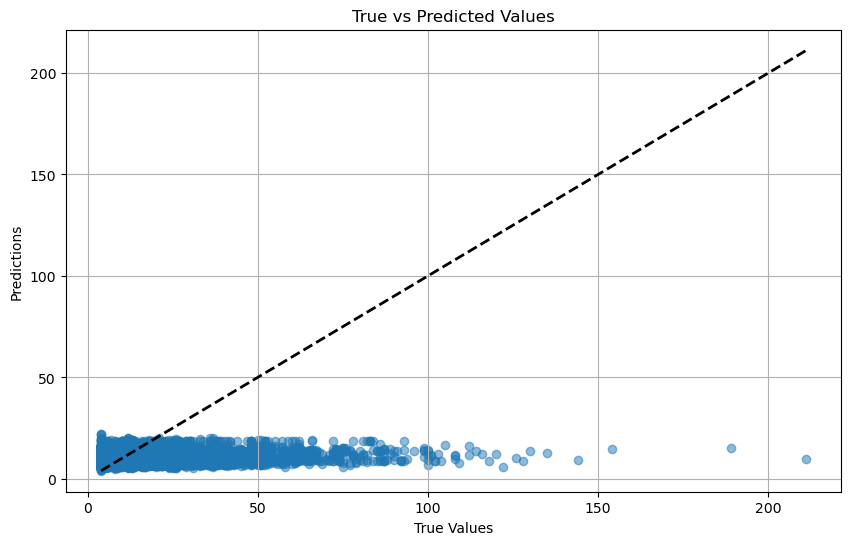

In [15]:
##################
# DNN 
##################

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier, KerasRegressor
import warnings
warnings.filterwarnings("ignore")

# Importation des données

path = os.path.join( "..", "data", "processed", "score_preprocessed.csv")
df = pd.read_csv(path)


# === 1. Split data
X = df.drop(columns=['score'])
y = df['score']

# Toutes les features sont catégorielles : conversion en string pour OneHot
X = X.astype(str)

# Train/test split
X_train, X_test, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.2, random_state=42)

# === 2. Transformation log sur la cible
y_train = np.log1p(y_train_raw)
y_test  = np.log1p(y_test_raw)

# === 3. OneHotEncoder (dense)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
preproc = ColumnTransformer([("ohe", ohe, X.columns)], remainder='drop')

X_train_proc = preproc.fit_transform(X_train).astype("float32")
X_test_proc  = preproc.transform(X_test).astype("float32")

# === 4. Modèle DNN
input_dim = X_train_proc.shape[1]
model = Sequential([
    Dense(256, activation='relu', input_shape=(input_dim,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='linear')  # Régression → sortie continue
])

model.compile(optimizer='adam',
              loss='mse',         # mean squared error
              metrics=['mae'])    # mean absolute error

# === 5. Early stopping
es = EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')

# === 6. Entraînement
model.fit(X_train_proc, y_train,
          epochs=100,
          batch_size=128,
          validation_split=0.2,
          callbacks=[es],
          verbose=1)

# === 7. Prédiction
y_pred_log = model.predict(X_test_proc).flatten()
y_pred = np.expm1(y_pred_log)  # Revenir dans l’échelle d’origine

# === 8. Évaluation
rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred))
r2 = r2_score(y_test_raw, y_pred)

print(f"✅ R² score: {r2:.4f}")
print(f"✅ RMSE: {rmse:.2f}")

# === 9. Visualisation
plt.figure(figsize=(10, 6))
plt.scatter(y_test_raw, y_pred, alpha=0.5)
plt.plot([y_test_raw.min(), y_test_raw.max()],
         [y_test_raw.min(), y_test_raw.max()],
         'k--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values')
plt.grid(True)
plt.show()

R² : 0.06547117233276367
RMSE: 83.60272979736328


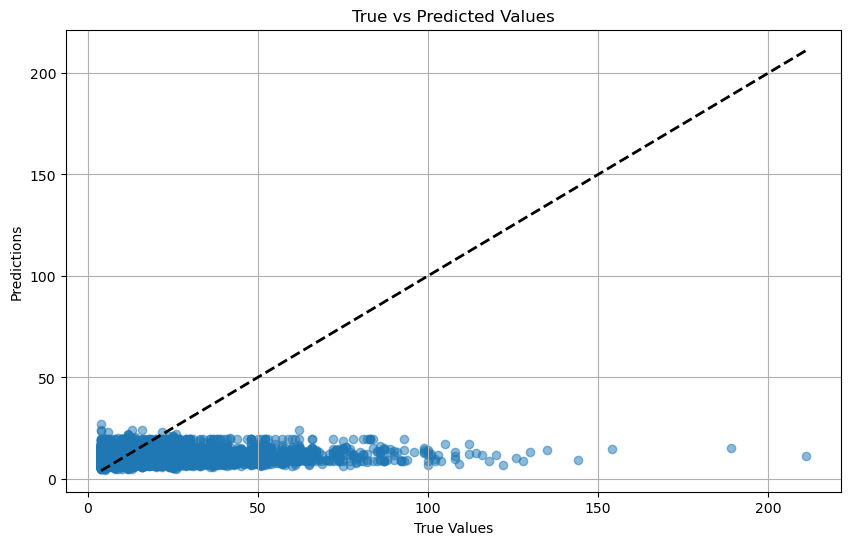

In [16]:
##################
# XGBoost 
##################

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_squared_error

# Importation des données   

path = os.path.join("..", "data", "processed", "score_preprocessed.csv")
df = pd.read_csv(path)          

# === 1. Split data
X = df.drop(columns=['score'])
y = df['score'] 

# One-hot (sparse=True par défaut)
ohe = OneHotEncoder(handle_unknown='ignore')
preproc = ColumnTransformer([('ohe', ohe, X.columns)], remainder='drop')

# Pipeline : OHE → XGB
xgb = XGBRegressor(
        n_estimators=600,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        tree_method='hist',            # accélère sur gros OHE
        eval_metric='rmse',
        n_jobs=-1,
        random_state=42)

pipe = Pipeline([('prep', preproc), ('xgb', xgb)])

pipe.fit(X_train, np.log1p(y_train_raw))             # on reste en log1p
y_pred_log = pipe.predict(X_test)
y_pred = np.expm1(y_pred_log)

print('R² :', r2_score(y_test_raw, y_pred))
print('RMSE:', mean_squared_error(y_test_raw, y_pred))

# === 9. Visualisation
plt.figure(figsize=(10, 6))
plt.scatter(y_test_raw, y_pred, alpha=0.5)
plt.plot([y_test_raw.min(), y_test_raw.max()],
         [y_test_raw.min(), y_test_raw.max()],
         'k--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values')
plt.grid(True)
plt.show()

Poisson  R² : 0.0795259075486977
Poisson RMSE: 82.3454021288257


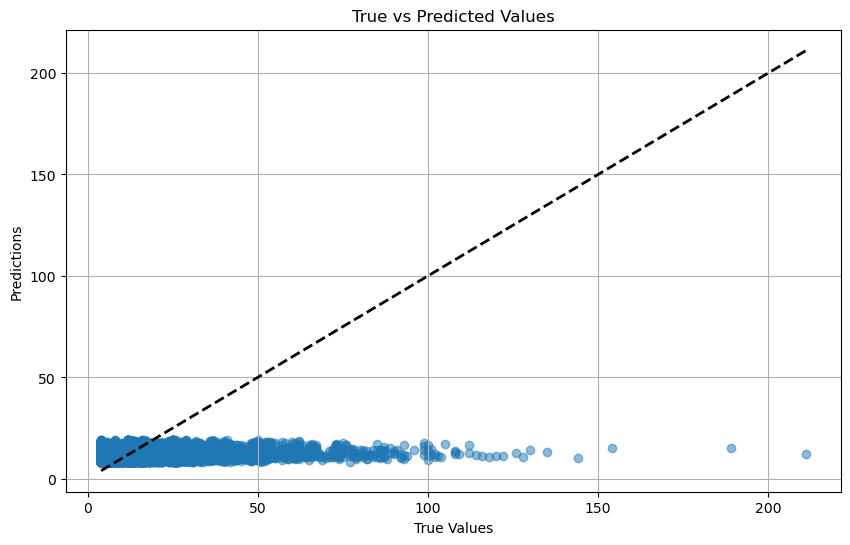

In [17]:
#################
# Poisson Regression
#################

import os
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

# Importation des données   

path = os.path.join("..", "data", "processed", "score_preprocessed.csv")
df = pd.read_csv(path)          

# --- Split
X = df.drop(columns=['score']).astype(str)
y = df['score']                       # déjà positive

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# --- One-Hot (sparse=True par défaut)
ohe = OneHotEncoder(handle_unknown='ignore')
preproc = ColumnTransformer([('ohe', ohe, X.columns)], remainder='drop')

# --- Pipeline Poisson
pipe_poisson = Pipeline([
    ('prep', preproc),
    ('glm',  PoissonRegressor(alpha=1.0, max_iter=300))   # alpha = régularisation L2
])

pipe_poisson.fit(X_train, y_train)
y_pred = pipe_poisson.predict(X_test)

print("Poisson  R² :", r2_score(y_test, y_pred))
print("Poisson RMSE:", mean_squared_error(y_test, y_pred))

# === 9. Visualisation
plt.figure(figsize=(10, 6))
plt.scatter(y_test_raw, y_pred, alpha=0.5)
plt.plot([y_test_raw.min(), y_test_raw.max()],
         [y_test_raw.min(), y_test_raw.max()],
         'k--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values')
plt.grid(True)
plt.show()